In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel


data = np.genfromtxt(
    "PS_2026.04.21_03.28.15.csv",
    delimiter=",",
    comments="#",
    dtype=float,
    filling_values=np.nan
)


data = np.delete(data, [1,2,3,7,9,10,11], axis=1) #delete errors and limit flag

data1 = []

for n in range(len(data)):
    if (np.isnan(data[n,:]).any() == False):
        data1.append(data[n, :])

data1 = np.array(data1)
data2  = np.array(data1)

for n in range(len(data2)):
    data2[n,2] = (data2[n,2] - data2[n,3])/2 #take the mean of the 2 errors

sample_a = np.delete(data2,3, axis = 1)

In [2]:
print("number of planets in the dataset: ", len(sample_a))

number of planets in the dataset:  2914


In [3]:
#sample_a[:,0] #planet radius
#sample_a[:,1] #planet mass
#sample_a[:,2] #error an planetary mass
#sample_a[:,3] #stellar mass

In [4]:
sample_b = []
for n in range(len(sample_a)):
    if (sample_a[n,0] <= 5):
        sample_b.append(sample_a[n,0])
sample_b = np.array(sample_b)

In [5]:
print("number of planets in sample b: ", len(sample_b))

number of planets in sample b:  1145


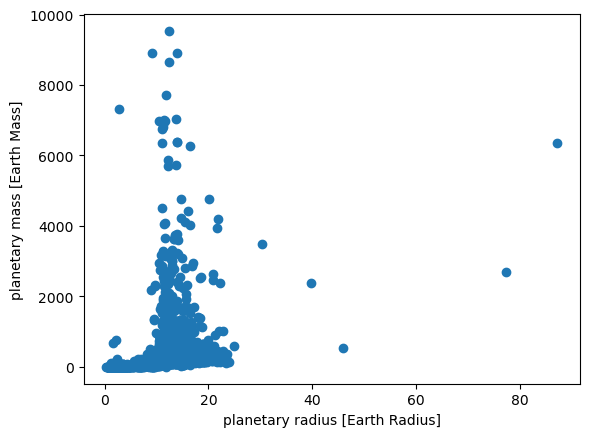

In [6]:
plt.scatter(sample_a[:,0], sample_a[:,1])
#plt.xscale('log')
#plt.yscale('log')
plt.xlabel('planetary radius [Earth Radius]')
plt.ylabel('planetary mass [Earth Mass]')
plt.savefig('planradmassnolog.png')

In [7]:
planet_r = sample_a[:, 0].copy()
planet_m = sample_a[:, 1].copy()
error_m = sample_a[:, 2].copy()
stellar_m = sample_a[:, 3].copy()

# log Transformation
log_planet_r = np.log10(planet_r)
log_stellar_m = np.log10(stellar_m)
log_planet_m = np.log10(planet_m)
log_error_m = error_m / (planet_m * np.log(10)) # relative error (we can't just apply logarithmic transformation to the error)

log_sample_a = np.column_stack((log_planet_r, log_planet_m, log_error_m, log_stellar_m))

In [8]:
(sample_a[:,1] == data2[:,1]).all()

np.True_

In [9]:
(log_sample_a[:,2] == log_error_m).all()

np.True_

In [10]:
#sample_a[:,0] #planet radius
#sample_a[:,1] #planet mass
#sample_a[:,2] #error an planetary mass
#sample_a[:,3] #stellar mass

In [12]:
#derive log sample_b:

log_sample_b = []
for n in range(len(log_sample_a)):
    if (log_sample_a[n,0] <= np.log(5)):
        log_sample_b.append(log_sample_a[n,:])
log_sample_b = np.array(log_sample_b)

## Single Kernel Model

Ignoring the uncertainties associated with the mass measurements, use a 1D linear regression model
to fit sample_B:

In [14]:
X = log_sample_a[:,0].copy()
Y = log_sample_a[:,1].copy()

X = X.reshape(-1,1)
Y = Y.reshape(-1,1)

alpha = log_sample_a[:,2].copy()
alpha = (alpha)**2


#kernel = RBF(length_scale=0.01)

kernel = RBF(
    length_scale=1,
    length_scale_bounds=(0.3, 10)
)

gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha= alpha,
    normalize_y=True
)

gp.fit(X, Y)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 0.3. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


,kernel,RBF(length_scale=1)
,alpha,"array([0.0265...shape=(2914,))"
,optimizer,'fmin_l_bfgs_b'
,n_restarts_optimizer,0
,normalize_y,True
,copy_X_train,True
,n_targets,None
,random_state,None
,kernel__length_scale,1
,kernel__length_scale_bounds,"(0.3, ...)"


In [15]:
print(gp.kernel_)

RBF(length_scale=0.3)


In [16]:
x_pred = np.linspace(log_sample_a[:,0].min(), log_sample_a[:,0].max(), 300).reshape(-1, 1)

y_pred, y_std = gp.predict(x_pred, return_std=True)

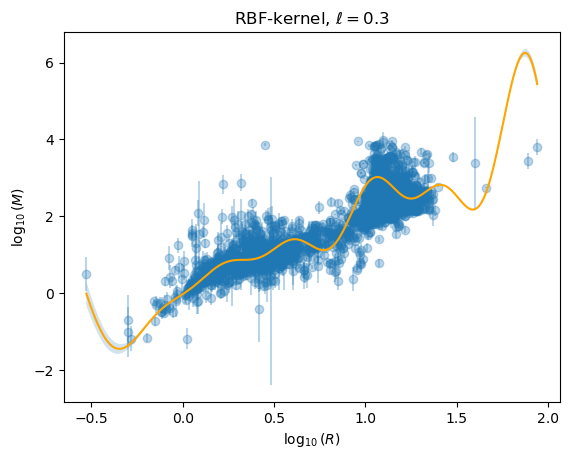

In [17]:
plt.plot(x_pred, y_pred, color='orange', zorder=3)
plt.errorbar(log_sample_a[:,0], log_sample_a[:,1], yerr=log_sample_a[:,2], fmt='o', alpha=0.3)

plt.fill_between(
    x_pred.flatten(),
    y_pred - y_std,
    y_pred + y_std,
    alpha=0.2
)

plt.xlabel('$\log_{10}(R)$')
plt.ylabel('$\log_{10}(M)$')
plt.title(f"RBF-kernel, $\ell = ${0.3}")
plt.savefig("firstplot.png")

/opt/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarn

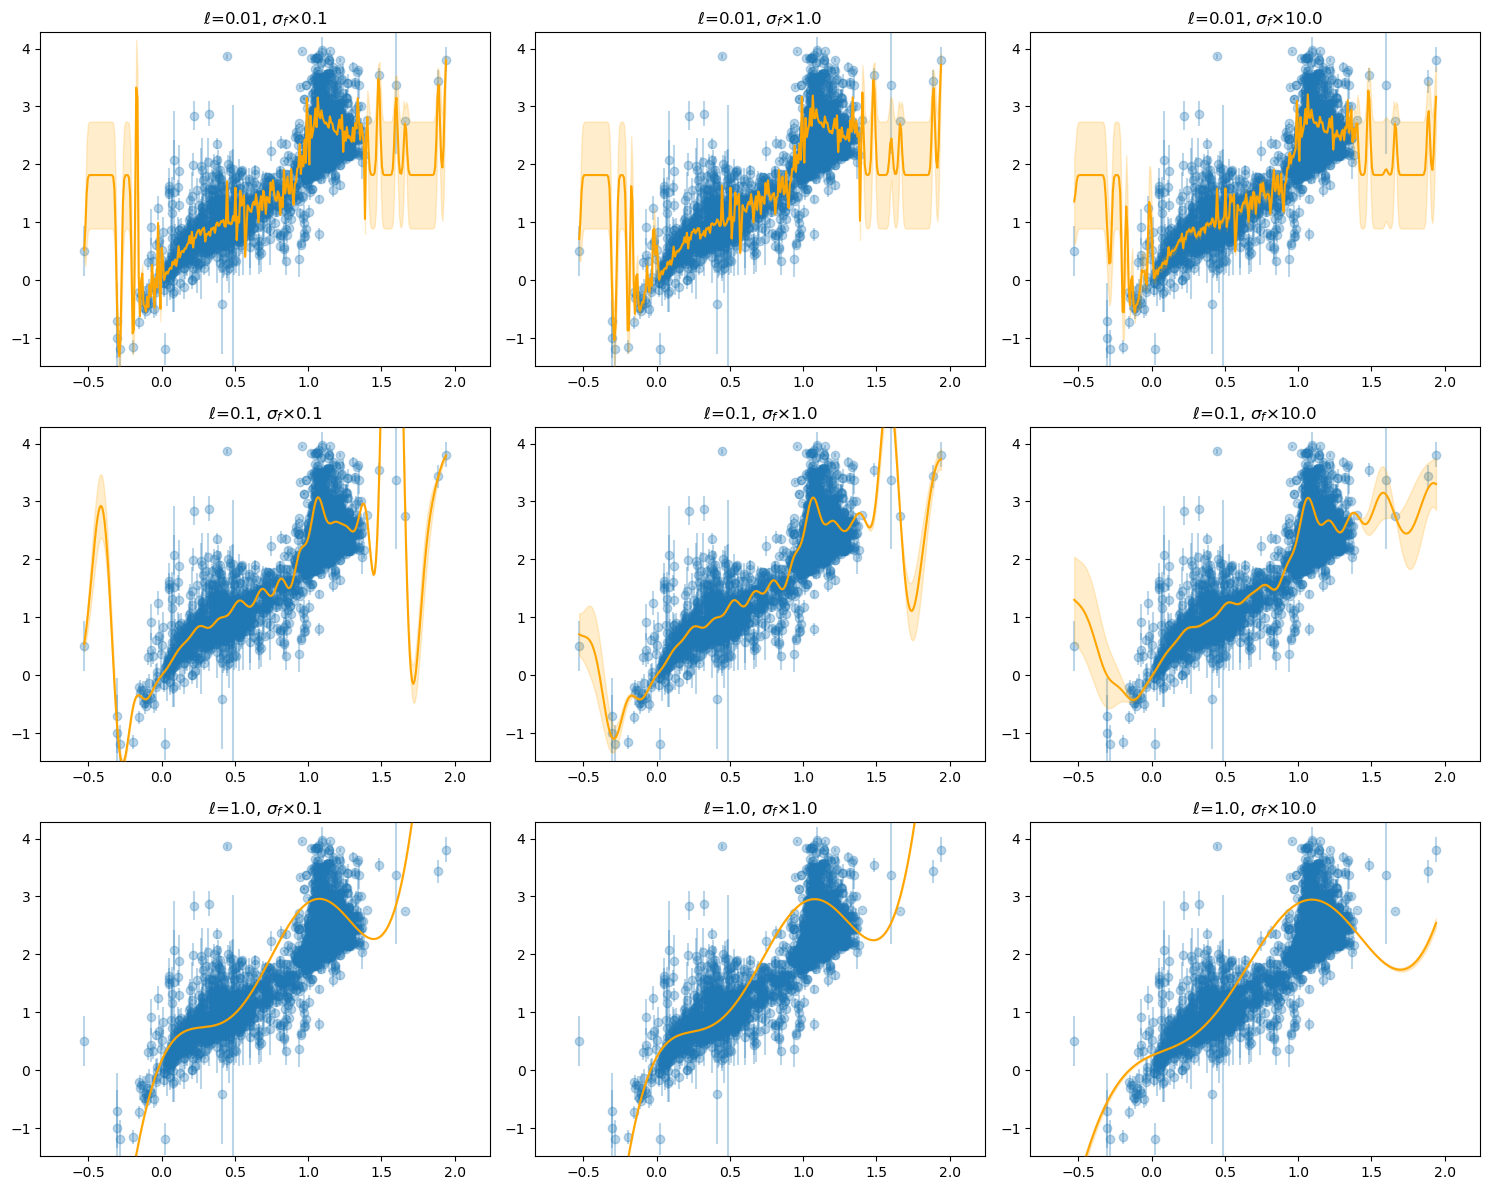

In [18]:
X = log_sample_a[:,0].reshape(-1,1)
Y = log_sample_a[:,1]

base_alpha = (log_sample_a[:,2])**2

length_scales = [0.01, 0.1, 1.0]
noise_scales = [0.1, 1.0, 10.0]

fig, axs = plt.subplots(3, 3, figsize=(15, 12))

x_pred = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)

for i, l in enumerate(length_scales):
    for j, ns in enumerate(noise_scales):

        alpha = base_alpha * ns

        kernel = RBF(length_scale=1.0,
                    length_scale_bounds = (l, 10))

        gp = GaussianProcessRegressor(
            kernel=kernel,
            alpha=alpha,
            normalize_y=True
        )

        gp.fit(X, Y)

        y_pred, y_std = gp.predict(x_pred, return_std=True)

        ax = axs[i, j]

        #ax.scatter(X, Y, alpha=0.3)
        ax.errorbar(X, Y, yerr=log_sample_a[:,2], fmt='o', alpha=0.3, zorder=1)

        ax.plot(x_pred, y_pred, color = "orange")
        ax.fill_between(
            x_pred.flatten(),
            y_pred - y_std,
            y_pred + y_std,
            color = "orange",
            alpha=0.2,
            zorder=3
        )

        ax.set_title(f"ℓ={l}, $\sigma_f$×{ns}")
        ax.set_xlim(X.min()-0.3, X.max()+0.3)
        ax.set_ylim(Y.min()-0.3, Y.max()+0.3)

plt.tight_layout()
plt.savefig("singlekernelmultparam.png")
plt.show()